# Neural machine translation: Transformer

In this demo, we implement a Transformer encoder-decoder model for our English-to-French translation task. The Transformer architecture differs fundamentally from RNN-based models by replacing recurrent layer entirely with **parallel attention**. Instead of processing tokens one at a time (like LSTMs), transformers process all tokens simultaneously using attention to capture relationships between words at any distance.

Recurrence is not necessary for sequence modeling. Transformers achieve better long-range dependency modeling with explicit positional encoding and self-attention and are being much faster to train due to parallelization.

### Key improvements

| LSTM + attention | Transformer |
|------------------|-------------|
| Sequential processing (one token at a time) | Parallel processing (all tokens simultaneously) |
| Position encoded implicitly through recurrence | Position encoded explicitly (sine/cosine functions) |
| Attention only in decoder (to encoder) | Self-attention in both encoder and decoder |
| Hidden states carry information forward | All positions attend to all positions |
| Slow training (cannot parallelize timesteps) | Fast training (full parallelization) |

### How transformers work

The original Transformer architecture consisted of an encoder-decoder architecture where both use **stacked attention layers** instead of recurrent layers.

**1. Positional encoding**

Since there's no recurrence to track position, we explicitly add positional information to the embeddings. The positional encoding is computed using sine and cosine functions of different frequencies:

$$\text{PE}(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

$$\text{PE}(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

Where $pos$ is the position in the sequence (which token: 0, 1, 2, ...) and $i$ is the dimension index within the embedding vector (which element: 0, 1, 2, ..., $d_{\text{model}}$-1). Each position gets a unique encoding pattern across all embedding dimensions, with different dimensions using different frequencies.

The positional encoding has the same dimensionality as the token embeddings ($d_{\text{model}}$), so they are **added element-wise**:

$$\text{input} = \text{embedding}(\text{token}) + \text{PE}(pos)$$

For example, the token "cat" at position 1 gets: `embedding("cat") + PE(1)`. This creates a single vector per token containing both semantic information (what the token means) and positional information (where it is in the sequence). These functions allow the model to learn to attend to relative positions, since for any fixed offset $k$, $\text{PE}(pos+k)$ can be represented as a linear function of $\text{PE}(pos)$.

**2. Self-attention in encoder**

Each encoder layer applies **self-attention**, where every token attends to all other tokens in the input sequence:

```text
Input:    "The"    "cat"    "sat"

Self-attention allows:
  "The" to attend to ["The", "cat", "sat"]
  "cat" to attend to ["The", "cat", "sat"]  
  "sat" to attend to ["The", "cat", "sat"]
```

This captures relationships like subject-verb agreement and word dependencies regardless of distance. The attention uses dot-product similarity:

$$\text{attention}(Q, K) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Where $Q$ (query), $K$ (key), and $V$ (value) are linear projections of the input.

**3. Masked self-attention in decoder**

During training, the decoder uses **masked self-attention** to prevent positions from attending to future positions (maintaining the autoregressive property):

```text
Target:   "<s>"  "Le"   "chat"

Masked self-attention:
  "<s>"  can attend to ["<s>"]
  "Le"   can attend to ["<s>", "Le"]
  "chat" can attend to ["<s>", "Le", "chat"]
```

This ensures the model learns to predict the next token using only previous context.

**4. Cross-attention**

After self-attention, the decoder applies **cross-attention** to the encoder outputs (same concept as LSTM attention):

```text
Encoder outputs: ["The", "cat", "sat"]
Decoder position: "chat"

Cross-attention: "chat" attends to ["The", "cat", "sat"]
  → High attention on "cat"
  → Low attention on "The" and "sat"
```

This allows the decoder to focus on relevant parts of the source sentence when generating each target token.

**5. Layer stacking and residual connections**

Both encoder and decoder consist of $N$ identical layers stacked on top of each other. Each layer has:
- Attention sub-layer (self or cross)
- Feed-forward sub-layer (two linear transformations with ReLU)
- Residual connections around each sub-layer
- Layer normalization after each sub-layer

The residual connections ($\text{output} = \text{LayerNorm}(x + \text{Sublayer}(x))$) help with gradient flow and allow the model to learn identity mappings when needed.

**Example:** When translating "The cat sat" → "Le chat", for generating "chat":
1. Encoder self-attention captures that "cat" is the subject
2. Decoder masked self-attention uses previous tokens "\<s>" and "Le" 
3. Decoder cross-attention focuses on "cat" in the encoder output
4. Feed-forward network processes the combined information
5. Output layer predicts "chat"

**Why this helps:**
- No sequential bottleneck: all positions processed in parallel
- Direct connections between any two positions (self-attention)
- Explicit modeling of position through encoding
- Better gradient flow through residual connections
- Scalable to very long sequences

### Implementation notes

This notebook uses a **simplified transformer** for teaching clarity:
- **Attention mechanism**: Simple dot-product attention (same as LSTM model), not multi-head attention
- **Focus**: Core concepts (positional encoding, self-attention, parallel processing)
- **Omitted**: Multi-head complexity, attention head splitting/concatenation

This keeps focus on understanding what makes transformers different without additional implementation complexity. The fundamental concepts (positional encoding, self-attention, parallel processing, residual connections) are all present.

### References

The Transformer architecture:

> Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. (2017). **Attention is all you need.** *Advances in Neural Information Processing Systems, 30.* https://arxiv.org/abs/1706.03762

The attention mechanism for neural machine translation:

> Bahdanau, D., Cho, K., & Bengio, Y. (2015). **Neural machine translation by jointly learning to align and translate.** *Proceedings of the 3rd International Conference on Learning Representations (ICLR).* https://arxiv.org/abs/1409.0473

The OPUS-100 dataset:

> Zhang, B., Williams, P., Titov, I., & Sennrich, R. (2020). **Improving massively multilingual neural machine translation and zero-shot translation.** *Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics (ACL).* https://arxiv.org/abs/2004.11867

## Notebook set-up

### Imports

In [1]:
# Suppress TensorFlow warnings and select GPU
import logging
import os
import sys
from datetime import datetime

# Environment variables for TensorFlow. Note: these must
# be set BEFORE importing TensorFlow to take effect.
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow warnings
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # Select GPU, 0 for GPU 1, etc.

# Core libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# NLP and translation libraries
from datasets import load_dataset
from sacrebleu.metrics import BLEU
from transformers import MarianTokenizer

# Keras model components
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import TensorBoard, ReduceLROnPlateau

### Configuration

In [2]:
# Configure GPU memory growth to avoid OOM errors
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        print(f'GPU memory growth enabled for {len(gpus)} GPU(s)')

    except RuntimeError as e:
        print(f'GPU configuration error: {e}')

else:
    print('No GPU detected - using CPU')

# Add parent directory to sys.path to allow importing from src module
sys.path.append('..')

# Initialization
np.random.seed(315)
tf.random.set_seed(315)

GPU memory growth enabled for 1 GPU(s)


## 1. Data preparation

### 1.1. Load dataset

In [3]:
# Load OPUS-100 English-French dataset
dataset = load_dataset('Helsinki-NLP/opus-100', 'en-fr')

# Configuration
max_seq_length = 20
num_samples = 100000

# Filter by sequence length and sample
def filter_length(example):
    en_length = len(example['translation']['en'].split())
    fr_length = len(example['translation']['fr'].split())
    return en_length <= max_seq_length and fr_length <= max_seq_length

filtered_dataset = dataset['train'].filter(filter_length)
sampled_dataset = filtered_dataset.select(range(min(num_samples, len(filtered_dataset))))

# Extract parallel sentences
pairs = [(item['translation']['en'], item['translation']['fr']) for item in sampled_dataset]

print(f'Loaded {len(pairs):,} training pairs')
print(f'Max sequence length: {max_seq_length} tokens')
print(f'\nExample pairs:')
for i in range(3):
    en, fr = pairs[i]
    print(f'  EN: {en}')
    print(f'  FR: {fr}')
    print()

Loaded 100,000 training pairs
Max sequence length: 20 tokens

Example pairs:
  EN: The time now is 05:08 .
  FR: The time now is 05:05 .

  EN: Hello, what's that?
  FR: Qu'est-ce que c'est que ça ?

  EN: And then I will teach you everything i know.
  FR: Et alors, je t'apprendrai tout ce que je sais.



### 1.2. Tokenization

In [4]:
# Load pre-trained MarianTokenizer
tokenizer = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-en-fr')

num_tokens = len(tokenizer)
max_encoder_len = max_seq_length + 2  # +2 for BOS/EOS
max_decoder_len = max_seq_length + 4  # Extra space for decoder

print(f'Vocabulary size: {num_tokens:,} tokens')
print(f'Max encoder length: {max_encoder_len}')
print(f'Max decoder length: {max_decoder_len}')
print(f'PAD token: {tokenizer.pad_token} (id={tokenizer.pad_token_id})')
print(f'EOS token: {tokenizer.eos_token} (id={tokenizer.eos_token_id})')

Vocabulary size: 59,514 tokens
Max encoder length: 22
Max decoder length: 24
PAD token: <pad> (id=59513)
EOS token: </s> (id=0)


### 1.3. Prepare training data

Create input sequences for the transformer:
- **Encoder input**: Source language tokens
- **Decoder input**: Target language tokens (shifted right, starts with PAD as BOS)
- **Decoder target**: Target language tokens (ground truth)

In [5]:
# Tokenize all pairs
encoder_inputs = tokenizer(
    [en for en, _ in pairs], 
    padding='max_length',
    truncation=True,
    max_length=max_encoder_len,
    return_tensors='np'
)

decoder_inputs = tokenizer(
    [fr for _, fr in pairs],
    padding='max_length', 
    truncation=True,
    max_length=max_decoder_len,
    return_tensors='np'
)

# Extract arrays
encoder_input_data = encoder_inputs['input_ids']
decoder_input_texts = [fr for _, fr in pairs]

# Prepare decoder inputs (shift right, start with PAD as BOS)
raw_decoder_tokens = decoder_inputs['input_ids']
decoder_input_data = np.zeros_like(raw_decoder_tokens)
decoder_input_data[:, 0] = tokenizer.pad_token_id
decoder_input_data[:, 1:] = raw_decoder_tokens[:, :-1]

# Decoder targets (ground truth)
decoder_target_data = raw_decoder_tokens

print(f'Encoder input shape: {encoder_input_data.shape}')
print(f'Decoder input shape: {decoder_input_data.shape}')
print(f'Decoder target shape: {decoder_target_data.shape}')
print(f'\nExample encoding (first sample):')
en_text, fr_text = pairs[0]
print(f'English: "{en_text}"')
print(f'French: "{fr_text}"')
print(f'Encoder input: {encoder_input_data[0, :10]}...')
print(f'Decoder input: {decoder_input_data[0, :10]}...')
print(f'Decoder target: {decoder_target_data[0, :10]}...')

Encoder input shape: (100000, 22)
Decoder input shape: (100000, 24)
Decoder target shape: (100000, 24)

Example encoding (first sample):
English: "The time now is 05:08 ."
French: "The time now is 05:05 ."
Encoder input: [   35   195   453    32  6987    37  3140   250     0 59513]...
Decoder input: [59513    35   195   453    32  6987    37  3187   250     0]...
Decoder target: [   35   195   453    32  6987    37  3187   250     0 59513]...


## 2. Model definitions

This section defines all model components for the transformer architecture. We build:
1. **Positional encoding**: Adds position information to embeddings
2. **Encoder layer**: Self-attention + feed-forward with residual connections
3. **Decoder layer**: Masked self-attention + cross-attention + feed-forward
4. **Complete transformer**: Combines encoder and decoder stacks
5. **Translation function**: Greedy decoding for generating translations

**Transformer architecture:**

```text
      ENCODER                                                 DECODER
                                                          
  Input: "Hello world"                               Target: "<s> Bonjour monde"
          │                                                      │
          ▼                                                      ▼
   ┌──────────────┐                                       ┌──────────────┐
   │  Embedding   │                                       │  Embedding   │
   └──────┬───────┘                                       └──────┬───────┘
          │                                                      │
          ▼                                                      ▼
   ┌──────────────┐                                       ┌──────────────┐
   │ Positional   │                                       │ Positional   │
   │  Encoding    │                                       │  Encoding    │
   └──────┬───────┘                                       └──────┬───────┘
          │                                                      │
          ▼                                                      ▼
   ┌──────────────┐       Encoder output vectors         ┌──────────────┐
   │     Self     │ ────────────────────────────────────►│    Masked    │
   │  Attention   │      (all encoder positions)         │     Self     │
   │ (parallel)   │                                      │  Attention   │
   └──────┬───────┘                                      │  (causal)    │
          │                                              └──────┬───────┘
          ▼                                                     │
   ┌──────────────┐                                             ▼
   │ Feed Forward │                                      ┌──────────────┐
   │   Network    │                                      │    Cross     │
   └──────┬───────┘                                      │  Attention   │◄─┐
          │                                              │ (to encoder) │  │
          ▼                                              └──────┬───────┘  │
   ┌──────────────┐                                             │          │
   │ Layer Norm + │                                             ▼          │
   │   Residual   │                                       ┌──────────────┐ │
   └──────┬───────┘                                       │ Feed Forward │ │
          │                                               │   Network    │ │
          ▼                                               └─────┬────────┘ │
  (repeat N layers)                                             │          │
          │                                                     ▼          │
          │                                               ┌──────────────┐ │
          │                                               │ Layer Norm + │ │
          └───────────────────────────────────────────────┤   Residual   │─┘
                                                          └──────┬───────┘
                                                                 │
                                                                 ▼
                                                          (repeat N layers)
                                                                 │
                                                                 ▼
                                                          ┌──────────────┐
                                                          │    Dense     │
                                                          │  (softmax)   │
                                                          └──────┬───────┘
                                                                 │
                                                                 ▼
                                                           Output sequence
                                                                 │
                                                    ┌────────────┴────────────┐
                                                    ▼                         ▼
                                         Labels (shifted target)         Predictions
                                          "Bonjour monde </s>"       "Bonjour monde </s>"
                                                    │                         │
                                                    └─────────► Loss ◄────────┘

KEY DIFFERENCES FROM LSTM:
- Parallel processing: Encoder processes all tokens simultaneously
- Positional encoding: Explicit position information (LSTM encodes position implicitly)
- Self-attention: Each token attends to all tokens in sequence
- Residual connections: Direct paths from input to output (helps deep networks)
- No recurrence: Makes training more efficient on GPUs

ATTENTION MECHANISMS (single-head, dot-product):
- Self-Attention: Token attends to all tokens in same sequence
- Masked Self-Attention: Token only attends to previous tokens (causal)
- Cross-Attention: Decoder attends to encoder outputs (same as LSTM attention)

Note: Uses same Attention layer from LSTM model, not multi-head attention.
      Focus is on learning core transformer concepts without added complexity.
```

### 2.1. Positional encoding

Since transformers process sequences in parallel (not sequentially like LSTMs), we must explicitly encode position information. The transformer uses sine/cosine functions at different frequencies to create unique positional encodings for each position.

Each position gets a unique encoding across all $d_{model}$ dimensions. Different dimensions use different frequencies, so lower dimensions change rapidly across positions while higher dimensions change slowly. This visualization shows how different embedding dimensions (y-axis) encode different position frequencies (x-axis):

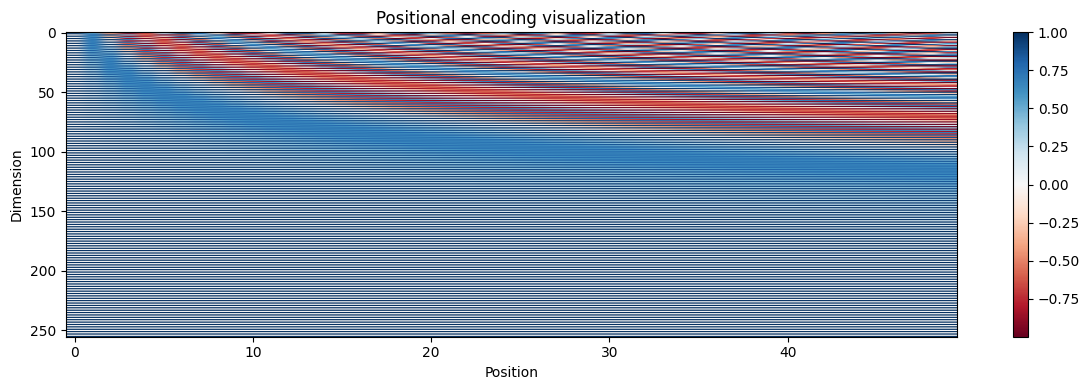

Positional encoding shape: (50, 256)


In [6]:
# Import positional encoding function from src module
from src.models import get_positional_encoding

# Visualize positional encoding
pos_enc = get_positional_encoding(50, 256)
plt.figure(figsize=(12, 4))
plt.imshow(pos_enc.T, aspect='auto', cmap='RdBu')
plt.colorbar()
plt.xlabel('Position')
plt.ylabel('Dimension')
plt.title('Positional encoding visualization')
plt.tight_layout()
plt.show()

print('Positional encoding shape:', pos_enc.shape)

### 2.2. Training model

The transformer model uses self-attention and cross-attention mechanisms with positional encodings. Unlike the LSTM model, transformers process sequences in parallel, making training more efficient.

Key components (all implemented using Keras layers):
- **Positional Encoding**: Adds position information via sine/cosine functions
- **Encoder Layers**: Self-attention + feed-forward network with residual connections
- **Decoder Layers**: Masked self-attention + cross-attention + feed-forward network
- **Attention**: Uses the same `layers.Attention` (dot-product) from the LSTM model

In [7]:
# Import model building function from src module
from src import build_transformer_model

# Model configuration
d_model = 256
n_layers = 4
d_ff = 512
dropout_rate = 0.1

# Build and compile transformer
model = build_transformer_model(
    num_tokens=num_tokens,
    max_encoder_len=max_encoder_len,
    max_decoder_len=max_decoder_len,
    d_model=d_model,
    n_layers=n_layers,
    d_ff=d_ff,
    dropout_rate=dropout_rate
)

print('Transformer model built')
print(f'Parameters: d_model={d_model}, n_layers={n_layers}, d_ff={d_ff}')
print(f'Dropout rate: {dropout_rate}')
print(f'\nNote: Uses simple dot-product attention (same as LSTM model), not multi-head')

Transformer model built
Parameters: d_model=256, n_layers=4, d_ff=512
Dropout rate: 0.1

Note: Uses simple dot-product attention (same as LSTM model), not multi-head


### 2.3. Translation function

The translation function implements greedy decoding for the transformer. Unlike the LSTM model, we don't need separate inference models - we can use the trained model directly for generation since the transformer's architecture naturally supports autoregressive decoding.

In [8]:
# Import translate function from src module
from src import translate_transformer

## 3. Model training

### 3.1. Callbacks

In [ ]:
# Import BLEU callback and dummy inference function from src module
from src import BLEUCallback, build_inference_models_transformer

# Create directories for checkpoints and logs
model_dir = '../models/transformer'
checkpoint_dir = f'{model_dir}/checkpoints'
log_dir = '../logs/transformer'
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

callbacks = [

    # BLEU evaluation/checkpointing callback
    BLEUCallback(
        pairs=pairs,
        tokenizer=tokenizer,
        max_encoder_len=max_encoder_len,
        max_decoder_len=max_decoder_len,
        translate_fn=translate_transformer,
        build_inference_fn=build_inference_models_transformer,
        checkpoint_dir=checkpoint_dir,
        sample_size=100,
        latent_dim=d_model,
        restore_best_weights=True
    ),

    # ReduceLROnPlateau callback - monitors BLEU score and reduces learning rate when it plateaus
    ReduceLROnPlateau(
        monitor='bleu_score',
        mode='max',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=0
    ),

    # TensorBoard callback for training visualization
    TensorBoard(
        log_dir=os.path.join(log_dir, datetime.now().strftime('%Y%m%d-%H%M%S')),
        histogram_freq=1,
        write_graph=True,
        write_images=False,
        update_freq='epoch'
    )
]

### 3.2. Train

In [10]:
%%time

# Train the model with all callbacks
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=64,
    epochs=30,
    validation_split=0.1,
    verbose=0,
    callbacks=callbacks
)

print(f'\nFinal training loss: {history.history["loss"][-1]:.4f}')
print(f'Final validation loss: {history.history["val_loss"][-1]:.4f}')
print(f'Best BLEU score: {callbacks[0].best_bleu:.2f}\n')

I0000 00:00:1772759125.286146 2031430 service.cc:145] XLA service 0x7472e8c62940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772759125.286195 2031430 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772759125.402079 2031430 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 16: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 19: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 22: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 25: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.

Epoch 28: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.


KeyboardInterrupt: 

In [ ]:
# Save training metrics
import json
from pathlib import Path

bleu_callback = callbacks[0]

# Create complete training history with BLEU scores
training_history = {
    'loss': history.history['loss'],
    'accuracy': history.history['accuracy'],
    'val_loss': history.history['val_loss'],
    'val_accuracy': history.history['val_accuracy'],
    'bleu_score': bleu_callback.bleu_scores
}

# Prepare checkpoint filename
checkpoint_filename = f'model_epoch_{bleu_callback.best_epoch+1:02d}_best_bleu_{bleu_callback.best_bleu:.2f}.h5'

# Create metrics dictionary
training_metrics = {
    'training_history': training_history,
    'best_epoch': bleu_callback.best_epoch,
    'best_bleu': bleu_callback.best_bleu,
    'checkpoint_file': checkpoint_filename
}

# Save to file
metrics_path = Path(model_dir) / 'training_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(training_metrics, f, indent=2)

print(f'Saved training metrics to {metrics_path}')

### 3.3. Learning curves

**Viewing TensorBoard logs:** To visualize training metrics (loss, accuracy, BLEU score) in TensorBoard:
1. Open the Command Palette (Ctrl+Shift+P / Cmd+Shift+P)
2. Run: "Python: Launch TensorBoard"
3. Select the log directory: `logs/transformer`

In [ ]:
bleu_callback = callbacks[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history.history['loss'], label='Training')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and validation loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Training')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and validation accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# BLEU
axes[2].plot(bleu_callback.bleu_scores, label='BLEU', color='green')
axes[2].axhline(y=bleu_callback.best_bleu, color='r', linestyle='--', 
                label=f'Best: {bleu_callback.best_bleu:.2f}')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('BLEU Score')
axes[2].set_title('BLEU score evolution')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Evaluation

### 4.1. Test translations

In [ ]:
# Test sentences
test_sentences = [
    "Hello, how are you?",
    "I love learning languages.",
    "The weather is beautiful today.",
    "She went to the market.",
    "Can you help me?"
]

print('Test translations:\n')
for sent in test_sentences:
    translation = translate_transformer(
        sent, model, tokenizer, max_encoder_len, max_decoder_len
    )
    print(f'EN: {sent}')
    print(f'FR: {translation}')
    print()

### 4.2. Compare with LSTM models

Load BLEU scores from training metrics to compare performance across architectures.

In [ ]:
# Load metrics from all models
import json

models_to_compare = {
    'LSTM': '../models/lstm/training_metrics.json',
    'LSTM + Attention': '../models/lstm-attention/training_metrics.json',
    'Transformer': '../models/transformer/training_metrics.json'
}

comparison_data = {}
for name, path in models_to_compare.items():
    if os.path.exists(path):
        with open(path, 'r') as f:
            metrics = json.load(f)
            comparison_data[name] = {
                'best_bleu': metrics['best_bleu'],
                'best_epoch': metrics['best_epoch'],
                'bleu_history': metrics['training_history']['bleu_score']
            }

# Plot comparison
plt.figure(figsize=(10, 6))
for name, data in comparison_data.items():
    plt.plot(data['bleu_history'], label=f"{name} (best: {data['best_bleu']:.2f})")

plt.xlabel('Epoch')
plt.ylabel('BLEU Score')
plt.title('Model comparison: BLEU score evolution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary
print('\nModel performance summary:')
print('-' * 50)
for name, data in comparison_data.items():
    print(f"{name:20s} Best BLEU: {data['best_bleu']:6.2f} (epoch {data['best_epoch']+1})")

## 5. The transformer family

The transformer architecture introduced in "Attention is All You Need" (2017) became the foundation for modern NLP. While we implemented an encoder-decoder model for translation, the transformer's modular design spawned specialized variants optimized for different tasks.

### Architecture variants

The original transformer has three main components that can be used independently:

**1. Encoder only (BERT family)**
- **Architecture**: Only the encoder stack (self-attention + feed-forward)
- **Training**: Masked language modeling (predict masked tokens)
- **Use cases**: Text classification, named entity recognition, question answering
- **Examples**: BERT, RoBERTa, DistilBERT
- **Key insight**: Bidirectional context (can see both left and right)

**2. Decoder only (GPT family)**
- **Architecture**: Only the decoder stack (causal self-attention + feed-forward)
- **Training**: Autoregressive language modeling (predict next token)
- **Use cases**: Text generation, completion, few-shot learning
- **Examples**: GPT-2, GPT-3, GPT-4, LLaMA
- **Key insight**: Unidirectional context (only sees left, generates right)

**3. Encoder-decoder (T5 family)**
- **Architecture**: Full transformer (both encoder and decoder)
- **Training**: Span corruption (predict masked spans)
- **Use cases**: Translation, summarization, question answering (as text generation)
- **Examples**: T5, BART, mT5
- **Key insight**: Flexible input-output (any text-to-text task)

### Transformer family tree

Our journey through neural machine translation and the broader transformer ecosystem:

```text
                           OUR IMPLEMENTATION JOURNEY
                                      
                              LSTM (Notebook 1)
                              [Sequential RNN]
                                     |
                                     ↓
                         LSTM + Attention (Notebook 2)
                        [RNN with attention mechanism]
                                     |
                                     ↓
                    ENCODER-DECODER TRANSFORMER (Notebook 3)
                Vaswani et al. 2017 - "Attention is All You Need"
                         [Parallel self-attention]
                                     |
                                     |
              _______________________|_______________________
             |                       |                       |
             |                       |                       |
       ENCODER ONLY            DECODER ONLY           ENCODER-DECODER
     (Bidirectional)        (Autoregressive)           (Seq-to-Seq)
             |                       |                       |
             |                       |                       |
        BERT (2018)              GPT (2018)              T5 (2019)
     Text understanding       Text generation           Text-to-text
             |                       |                       |
             ↓                       ↓                       ↓
        - RoBERTa              - GPT-2, GPT-3              - BART
        - DistilBERT           - ChatGPT                   - mT5
        - ALBERT               - GPT-4                     - mBART
        - ELECTRA              - LLaMA, Mistral


ARCHITECTURE EVOLUTION:

                 LSTM → LSTM+Attention → Transformer
    
    Processing:         Sequential    Sequential       Parallel
    Position Info:      Implicit      Implicit         Explicit
    Attention:          None          Decoder only     Everywhere
    Training Speed:     Slow          Slow             Fast


TYPICAL USE CASES:

Encoder Only:                  Decoder Only:              Encoder-Decoder:
- Text classification          - Text generation          - Translation
- Named entity recognition     - Creative writing         - Summarization  
- Question answering           - Code completion          - Question answering
- Sentiment analysis           - Chatbots                 - Text simplification
- Token classification         - Few-shot learning        - Style transfer
```

### Task-specific design choices

**Why encoder-only for understanding tasks?**
- Needs full context (both directions) to understand meaning
- Example: "The bank was steep" vs "I went to the bank"
  - Classification needs to see entire sentence to disambiguate
- Bidirectional attention captures relationships in all directions

**Why decoder-only for generation tasks?**
- Generates tokens left-to-right (autoregressive)
- Training matches inference (both predict next token)
- Example: "The cat sat on the ___" → predicts "mat"
- Causal masking prevents looking ahead during training

**Why encoder-decoder for sequence-to-sequence?**
- Input and output have different structures
- Example: English → French, long document → summary
- Encoder: bidirectional understanding of source
- Decoder: autoregressive generation of target
- Cross-attention: aligns source and target

### T5 unified framework

T5 (Text-to-Text Transfer Transformer) reframes all NLP tasks as text generation:

```text
Translation:      "translate English to French: Hello" → "Bonjour"
Classification:   "sentiment: This movie is great"     → "positive"
Summarization:    "summarize: [long text]"             → "[summary]"
Question answer:  "question: Who? context: [text]"     → "John"
```

This unified approach means:
- Same architecture for all tasks
- Task specified by input prefix
- All outputs are generated text
- Single model can handle multiple tasks

**Comparison to our implementation:**
- Our model: Specialized for translation (English → French)
- T5: General purpose (any text → any text)
- Both: Use same core transformer blocks we implemented

### Key takeaways

1. **Modularity**: Encoder and decoder are independent building blocks
2. **Task alignment**: Architecture choice matches task requirements
3. **Pre-training**: Modern models pre-train on massive corpora, then fine-tune
4. **Scaling**: Larger models (more layers, wider dimensions) generally perform better
5. **Simplification**: Recent trend toward decoder-only (simpler, scales well)

### From our implementation to production models

Our simplified transformer demonstrates core concepts:
- Positional encoding (how to add position information)
- Self-attention (how tokens attend to each other)
- Cross-attention (how decoder attends to encoder)
- Layer stacking (how depth improves performance)

Production transformers add:
- **Multi-head attention**: Multiple attention patterns in parallel
- **Larger scale**: 12-96+ layers, 768-12288 dimensions
- **Pre-training**: Learn from billions of tokens before fine-tuning
- **Tokenization**: Subword units (BPE, WordPiece, SentencePiece)
- **Optimization**: Mixed precision, gradient checkpointing, distributed training

The fundamental architecture remains the same.